# NOTE that pycolmap needs to be downgraded to 0.6.0 cause the API name has been changed afterwars.

In [12]:
import tqdm, tqdm.notebook
tqdm.tqdm = tqdm.notebook.tqdm  # notebook-friendly progress bars
from pathlib import Path

from hloc import extract_features, match_features, reconstruction, visualization, pairs_from_exhaustive
from hloc.visualization import plot_images, read_image
from hloc.utils import viz_3d

# Setup
Here we define some output paths. We will use SuperPoint local features with the SuperGlue matcher, but it's easy to switch to other features like SIFT or R2D2.

In [13]:
images = Path('../images/')
outputs = Path('../images/outputs/')
sfm_pairs = outputs / 'pairs-sfm.txt'
loc_pairs = outputs / 'pairs-loc.txt'
sfm_dir = outputs / 'sfm'
features = outputs / 'features.h5'
matches = outputs / 'matches.h5'

feature_conf = extract_features.confs['disk']
matcher_conf = match_features.confs['disk+lightglue']

# 3D mapping
First we list the images used for mapping. These are shot around plant

10 mapping images


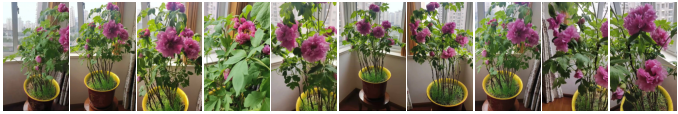

In [14]:
references = [str(p.relative_to(images)) for p in (images / 'mapping/').iterdir()]
print(len(references), "mapping images")
plot_images([read_image(images / r) for r in references], dpi=25)

Then we extract features and match them across image pairs. Since we deal with few images, we simply match all pairs exhaustively. For larger scenes, we would use image retrieval, as demonstrated in the other notebooks.

In [15]:
extract_features.main(feature_conf, images, image_list=references, feature_path=features)
# pairs_from_exhaustive.main(sfm_pairs, image_list=references)
match_features.main(matcher_conf, sfm_pairs, features=features, matches=matches);

[2025/01/24 00:11:46 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 5000, 'name': 'disk'},
 'output': 'feats-disk',
 'preprocessing': {'grayscale': False, 'resize_max': 1600}}
[2025/01/24 00:11:46 hloc INFO] Skipping the extraction.
[2025/01/24 00:11:46 hloc INFO] Matching local features with configuration:
{'model': {'features': 'disk', 'name': 'lightglue'},
 'output': 'matches-disk-lightglue'}
[2025/01/24 00:11:46 hloc INFO] Skipping the matching.


Then we run incremental Structure-from-Motion...

In [16]:
model = reconstruction.main(sfm_dir, images, sfm_pairs, features, matches, image_list=references)

[2025/01/24 00:11:46 hloc WARNING] The database already exists, deleting it.
[2025/01/24 00:11:46 hloc INFO] Creating an empty database...
[2025/01/24 00:11:46 hloc INFO] Importing images into the database...
[2025/01/24 00:11:46 hloc INFO] Importing features into the database...


  0%|          | 0/10 [00:00<?, ?it/s]

[2025/01/24 00:11:46 hloc INFO] Importing matches into the database...


  0%|          | 0/45 [00:00<?, ?it/s]

[2025/01/24 00:11:46 hloc INFO] Performing geometric verification of the matches...
I20250124 00:11:46.409668 27152 misc.cc:198] 
Custom feature matching
I20250124 00:11:46.411432 27152 feature_matching.cc:1021] Matching block [1/1]
I20250124 00:11:46.673789 27152 feature_matching.cc:46]  in 0.262s
I20250124 00:11:46.674069 27152 timer.cc:91] Elapsed time: 0.004 [minutes]
[2025/01/24 00:11:46 hloc INFO] Running 3D reconstruction...
I20250124 00:11:46.676728 27221 misc.cc:198] 
Loading database
I20250124 00:11:46.677460 27221 database_cache.cc:54] Loading cameras...
I20250124 00:11:46.677495 27221 database_cache.cc:64]  10 in 0.000s
I20250124 00:11:46.677507 27221 database_cache.cc:72] Loading matches...
I20250124 00:11:46.677690 27221 database_cache.cc:78]  18 in 0.000s
I20250124 00:11:46.677700 27221 database_cache.cc:94] Loading images...
I20250124 00:11:46.679191 27221 database_cache.cc:143]  10 in 0.001s (connected 9)
I20250124 00:11:46.679208 27221 database_cache.cc:154] Building 

and display the reconstructed 3D model:

In [17]:
fig = viz_3d.init_figure()
viz_3d.plot_reconstruction(fig, model, color='rgba(255,0,0,0.5)', name="mapping", points_rgb=True)
fig.show()

We also visualize which keypoints were triangulated into the 3D model.

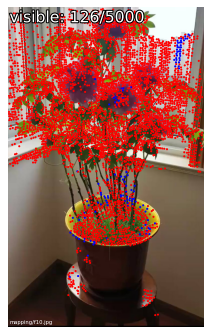

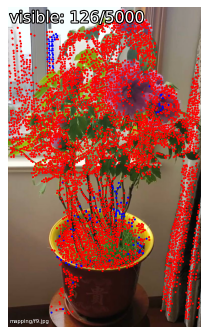

In [18]:
visualization.visualize_sfm_2d(model, images, color_by='visibility', n=2)

# Localization
Now that we have a 3D map of the scene, we can localize any image.

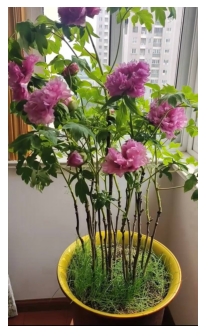

In [19]:
query = '../images/query/fq.jpg'
plot_images([read_image(query)], dpi=75)

Again, we extract features for the query and match them exhaustively with all mapping images that were successfully reconstructed.

In [20]:
references_registered = [model.images[i].name for i in model.reg_image_ids()]
extract_features.main(feature_conf, images, image_list=[query], feature_path=features, overwrite=True)
pairs_from_exhaustive.main(loc_pairs, image_list=[query], ref_list=references_registered)
match_features.main(matcher_conf, loc_pairs, features=features, matches=matches, overwrite=True);

[2025/01/24 00:11:47 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 5000, 'name': 'disk'},
 'output': 'feats-disk',
 'preprocessing': {'grayscale': False, 'resize_max': 1600}}


  0%|          | 0/1 [00:00<?, ?it/s]

[2025/01/24 00:11:47 hloc INFO] Finished exporting features.
[2025/01/24 00:11:47 hloc INFO] Found 2 pairs.
[2025/01/24 00:11:47 hloc INFO] Matching local features with configuration:
{'model': {'features': 'disk', 'name': 'lightglue'},
 'output': 'matches-disk-lightglue'}


  0%|          | 0/2 [00:00<?, ?it/s]

[2025/01/24 00:11:48 hloc INFO] Finished exporting matches.


We read the EXIF data of the query to infer a rough initial estimate of camera parameters like the focal length. Then we estimate the absolute camera pose using PnP+RANSAC and refine the camera parameters.

found 10/25 inlier correspondences.
Rotation matrix Rc:
 [[ 0.67885921  0.0449947   0.73288857]
 [ 0.09609793  0.98409132 -0.14943043]
 [-0.72795286  0.1718713   0.66373556]]
Translation vector tc:
 [-1.38086781e+01  4.62105906e+00  6.80630480e+03]


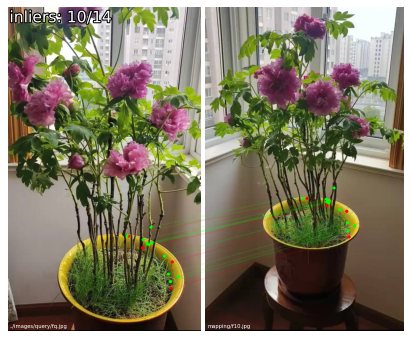

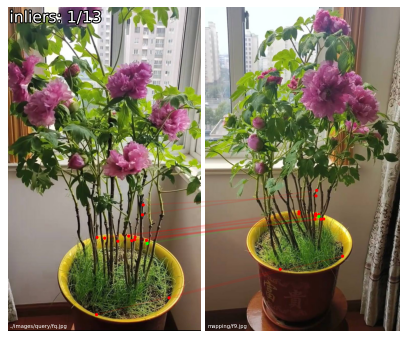

In [42]:
import pycolmap
from hloc.localize_sfm import QueryLocalizer, pose_from_cluster
import numpy as np

camera = pycolmap.infer_camera_from_image(images / query)
ref_ids = [model.find_image_with_name(n).image_id for n in references_registered]
conf = {
    'estimation': {'ransac': {'max_error': 12}},
    'refinement': {'refine_focal_length': True, 'refine_extra_params': True},
}
localizer = QueryLocalizer(model, conf)
ret, log = pose_from_cluster(localizer, query, camera, ref_ids, features, matches)

print(f'found {ret["num_inliers"]}/{len(ret["inliers"])} inlier correspondences.')

Rc = np.array(ret["cam_from_world"].rotation.matrix())
tc = ret["cam_from_world"].translation

print("Rotation matrix Rc:\n", Rc)
print("Translation vector tc:\n", tc)
visualization.visualize_loc_from_log(images, query, log, model)

We visualize the correspondences between the query images a few mapping images. We can also visualize the estimated camera pose in the 3D map.

In [22]:
pose = pycolmap.Image(cam_from_world=ret['cam_from_world'])
viz_3d.plot_camera_colmap(fig, pose, camera, color='rgba(0,255,0,0.5)', name=query, fill=True)
# visualize 2D-3D correspodences
import numpy as np
inl_3d = np.array([model.points3D[pid].xyz for pid in np.array(log['points3D_ids'])[ret['inliers']]])
viz_3d.plot_points(fig, inl_3d, color="lime", ps=1, name=query)
fig.show()